In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install nbformat ipython

Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 7043, Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()
df.isnull().sum()
df['Churn'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Diccionario de datos

| Columna | Descripción | Valores |
|---|---|---|
| customerID | ID único del cliente | texto |
| gender | Género del cliente | Male / Female |
| SeniorCitizen | Si es adulto mayor | 0 / 1 |
| Partner | Si tiene pareja | Yes / No |
| Dependents | Si tiene dependientes | Yes / No |
| tenure | Meses que lleva como cliente | numérico |
| PhoneService | Tiene servicio telefónico | Yes / No |
| MultipleLines | Tiene múltiples líneas | Yes / No / No phone service |
| InternetService | Tipo de servicio de internet | DSL / Fiber optic / No |
| OnlineSecurity | Tiene seguridad online | Yes / No / No internet service |
| OnlineBackup | Tiene backup online | Yes / No / No internet service |
| DeviceProtection | Tiene protección de dispositivo | Yes / No / No internet service |
| TechSupport | Tiene soporte técnico | Yes / No / No internet service |
| StreamingTV | Tiene streaming de TV | Yes / No / No internet service |
| StreamingMovies | Tiene streaming de películas | Yes / No / No internet service |
| Contract | Tipo de contrato | Month-to-month / One year / Two year |
| PaperlessBilling | Facturación electrónica | Yes / No |
| PaymentMethod | Método de pago | varias categorías |
| MonthlyCharges | Cargo mensual | numérico |
| TotalCharges | Cargo total acumulado | numérico |
| Churn | **Variable objetivo**: si canceló el servicio | Yes / No |

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Valores nulos generados: {df['TotalCharges'].isnull().sum()}")
df[df['TotalCharges'].isnull()][['customerID','tenure','MonthlyCharges','TotalCharges']]
# Como tenure=0, su cargo total acumulado es 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Valores nulos generados: 11


In [6]:
df.to_csv('../data/processed/customers_clean.csv', index=False)
df.shape

(7043, 21)

In [7]:
%pip install --upgrade nbformat ipython

^C
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall ipython None
╰─> The package's contents are unknown: no RECORD file was found for ipython.

hint: You might be able to recover from this via: pip install --ignore-installed --no-deps ipython==9.14.1


  Using cached ipython-9.17.1-py3-none-any.whl.metadata (4.6 kB)
Using cached ipython-9.17.1-py3-none-any.whl (639 kB)
  Attempting uninstall: ipython
    Found existing installation: ipython None


In [8]:
fig = px.histogram(df, x='Churn', color='Churn',
                    title='Distribución de Churn (variable objetivo)')
fig.write_html('../artifacts/eda_churn_distribution.html')
fig.show()

In [9]:
fig = px.histogram(df, x='Contract', color='Churn', barmode='group',
                    title='Churn por tipo de contrato')
fig.write_html('../artifacts/eda_churn_by_contract.html')
fig.show()

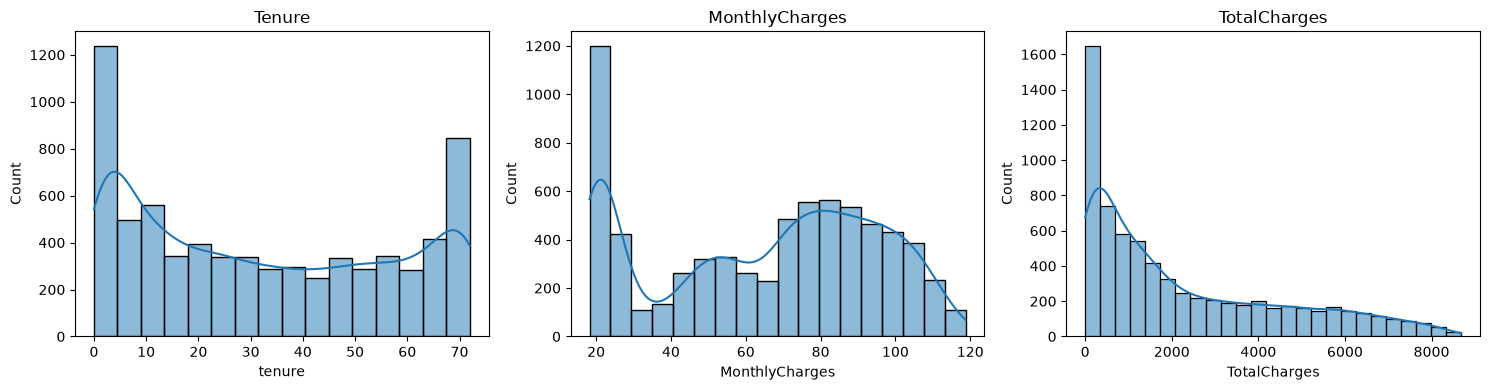

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['tenure'], kde=True, ax=axes[0]).set_title('Tenure')
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[1]).set_title('MonthlyCharges')
sns.histplot(df['TotalCharges'], kde=True, ax=axes[2]).set_title('TotalCharges')
plt.tight_layout()
plt.savefig('../artifacts/eda_distribuciones_numericas.png')
plt.show()

In [11]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

corr = numeric_df.corr()
fig = px.imshow(corr, text_auto=True, title='Matriz de correlación')
fig.write_html('../artifacts/eda_correlacion.html')
fig.show()

In [12]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [13]:
df_model = df.drop('customerID', axis=1)

categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"Columnas categóricas a codificar ({len(categorical_cols)}):")
print(categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"Shape después del encoding: {df_encoded.shape}")
df_encoded.head()

Columnas categóricas a codificar (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Shape después del encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [15]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

with open('../artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

df_encoded[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.169057e-17,-1.866398e-17,-1.715068e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [16]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Proporción Churn en train: {y_train.mean():.3f}")
print(f"Proporción Churn en test: {y_test.mean():.3f}")

Train: (5634, 30), Test: (1409, 30)
Proporción Churn en train: 0.265
Proporción Churn en test: 0.265


In [17]:
train_df = X_train.copy()
train_df['Churn'] = y_train

test_df = X_test.copy()
test_df['Churn'] = y_test

train_df.to_parquet('../data/processed/train.parquet', index=False)
test_df.to_parquet('../data/processed/test.parquet', index=False)

print("Archivos guardados en data/processed/")

Archivos guardados en data/processed/


In [18]:
# Guardar resumen del preprocesamiento para MLflow
#guarda el dataset limpio en un parquet, listo para usar en MLFlow
resumen_preprocesamiento = {
    'total_registros': len(df),
    'total_features_originales': df.shape[1] - 1,
    'total_features_encoded': X_train.shape[1],
    'registros_train': len(X_train),
    'registros_test': len(X_test),
    'proporcion_churn_train': round(y_train.mean(), 4),
    'proporcion_churn_test': round(y_test.mean(), 4),
    'columnas_con_nulos_corregidas': 1,  # TotalCharges
}

import json
with open('../artifacts/resumen_preprocesamiento.json', 'w') as f:
    json.dump(resumen_preprocesamiento, f, indent=2)

print("Resumen guardado en artifacts/resumen_preprocesamiento.json")
print(resumen_preprocesamiento)

Resumen guardado en artifacts/resumen_preprocesamiento.json
{'total_registros': 7043, 'total_features_originales': 20, 'total_features_encoded': 30, 'registros_train': 5634, 'registros_test': 1409, 'proporcion_churn_train': np.float64(0.2654), 'proporcion_churn_test': np.float64(0.2654), 'columnas_con_nulos_corregidas': 1}
